# Project 1: Credit Card Fraud Detection
## Exploratory Data Analysis (EDA)

**Dataset:** [Credit Card Fraud Detection – Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Tools:** Python, pandas, numpy, matplotlib, seaborn, scipy  
**Tujuan:** Memahami pola transaksi fraud vs normal sebelum membangun model ML

---
## Import Library & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Styling konsisten untuk semua chart
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FRAUD_COLOR   = '#E63946'   # merah — kelas fraud
NORMAL_COLOR  = '#457B9D'   # biru — kelas normal
ACCENT_COLOR  = '#F4A261'   # oranye — highlight

# Load dataset
df = pd.read_csv('creditcard.csv')

print('Dataset berhasil dimuat!')
print(f'   Jumlah baris  : {df.shape[0]:,}')
print(f'   Jumlah kolom  : {df.shape[1]}')

Dataset berhasil dimuat!
   Jumlah baris  : 284,807
   Jumlah kolom  : 31


---
## Struktur Data & Informasi Dasar

In [4]:
# Preview data
display(df.head())

print('\nTipe Data & Missing Values')
info_df = pd.DataFrame({
    'dtype'       : df.dtypes,
    'non_null'    : df.notnull().sum(),
    'missing'     : df.isnull().sum(),
    'missing_%'   : (df.isnull().sum() / len(df) * 100).round(2)
})
display(info_df)

print('\n Statistik Deskriptif: Amount & Time ')
display(df[['Time', 'Amount', 'Class']].describe().round(2))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Tipe Data & Missing Values


,dtype,non_null,missing,missing_%
Time,float64,284807,0,0.0
V1,float64,284807,0,0.0
V2,float64,284807,0,0.0
V3,float64,284807,0,0.0
V4,float64,284807,0,0.0
V5,float64,284807,0,0.0
V6,float64,284807,0,0.0
V7,float64,284807,0,0.0
V8,float64,284807,0,0.0
V9,float64,284807,0,0.0



 Statistik Deskriptif: Amount & Time 


,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


> **Insight awal:** Kolom V1–V28 adalah hasil PCA (Principal Component Analysis) dari fitur asli yang dirahasiakan oleh bank. Kita hanya bisa bekerja dengan `Time`, `Amount`, dan `Class` secara langsung.

---
## Distribusi Kelas (Class Imbalance)

Distribusi Kelas
  Normal (0) : 284,315 transaksi (99.8273%)
  Fraud  (1) : 492 transaksi (0.1727%)
  Rasio      : 1 fraud per 577 transaksi normal


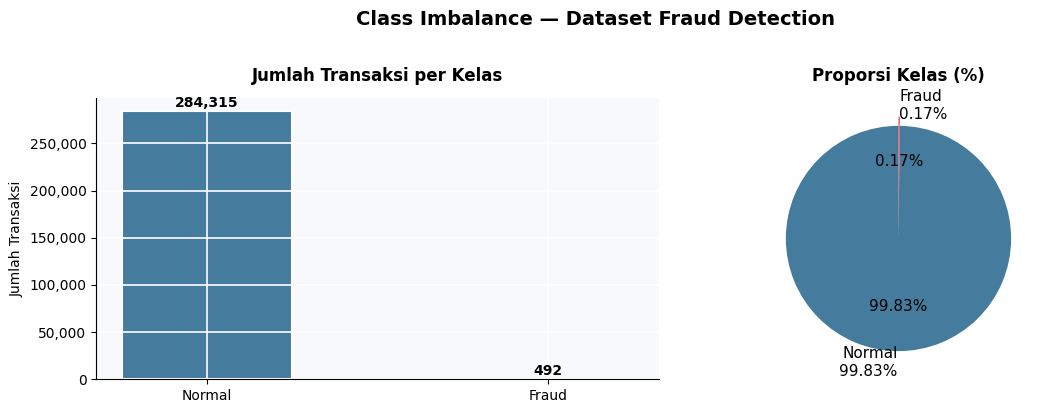

In [6]:
class_counts = df['Class'].value_counts()
fraud_pct    = class_counts[1] / len(df) * 100
normal_pct   = class_counts[0] / len(df) * 100

print('Distribusi Kelas')
print(f'  Normal (0) : {class_counts[0]:,} transaksi ({normal_pct:.4f}%)')
print(f'  Fraud  (1) : {class_counts[1]:,} transaksi ({fraud_pct:.4f}%)')
print(f'  Rasio      : 1 fraud per {class_counts[0]//class_counts[1]:,} transaksi normal')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    ['Normal', 'Fraud'],
    [class_counts[0], class_counts[1]],
    color=[NORMAL_COLOR, FRAUD_COLOR],
    width=0.5, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, [class_counts[0], class_counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Jumlah Transaksi per Kelas', fontweight='bold', pad=12)
axes[0].set_ylabel('Jumlah Transaksi')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(
    [normal_pct, fraud_pct],
    labels=[f'Normal\n{normal_pct:.2f}%', f'Fraud\n{fraud_pct:.2f}%'],
    colors=[NORMAL_COLOR, FRAUD_COLOR],
    explode=[0, 0.08],
    autopct='%1.2f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporsi Kelas (%)', fontweight='bold', pad=12)

plt.suptitle('Class Imbalance — Dataset Fraud Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

> **Class Imbalance:**  
> Dataset ini sangat tidak seimbang. Hanya ~0.17% transaksi yang merupakan fraud.
> Ini adalah tantangan utama di proyek fraud detection: model yang naif pun bisa mencapai akurasi >99% hanya dengan selalu memprediksi "normal".  
> **Solusi yang akan digunakan di Project 3:** SMOTE oversampling + evaluasi dengan F1-Score & AUC-ROC.

---
## Analisis Waktu Transaksi

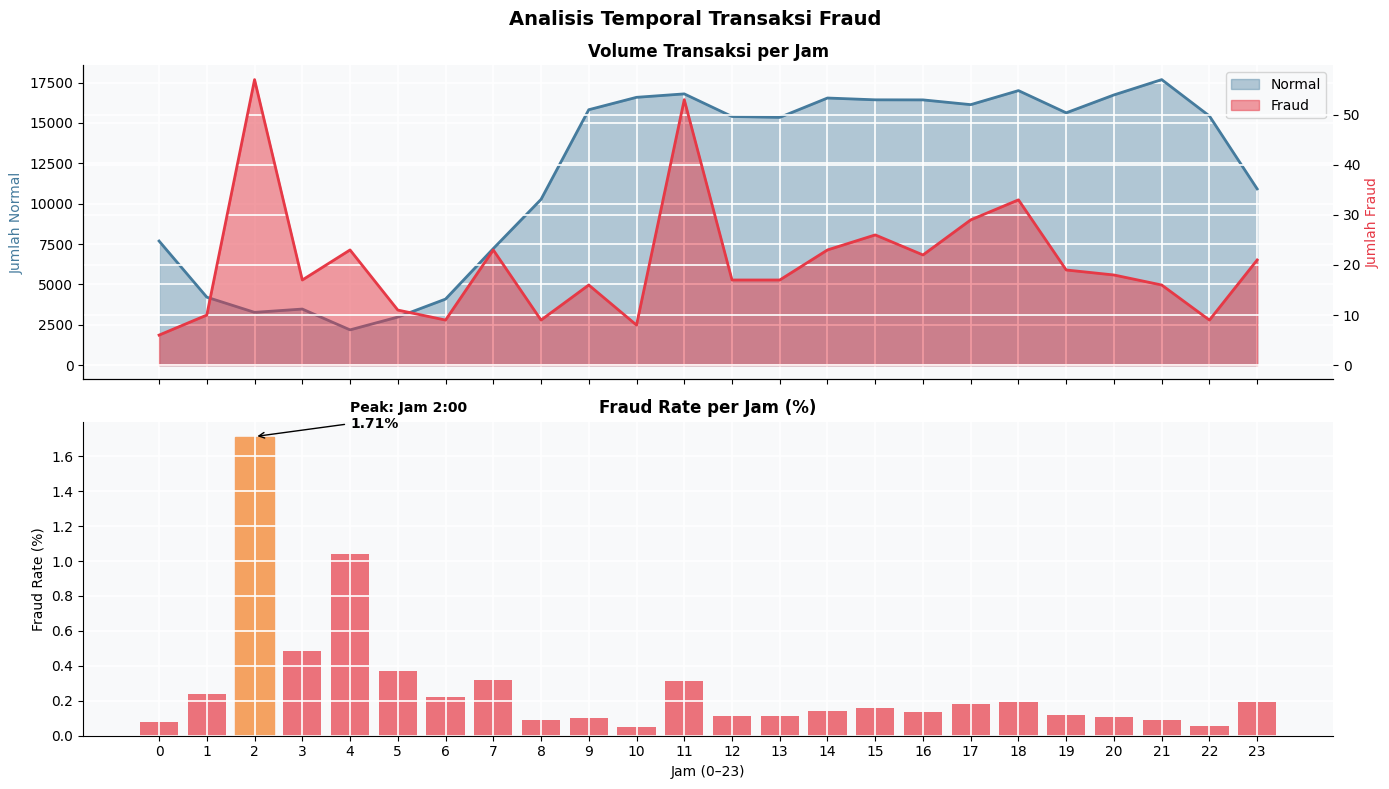


 Jam dengan fraud rate tertinggi: 2:00 (1.713%)
 Jam dengan transaksi terbanyak : 21:00 (17,703 transaksi)


In [11]:
# Konversi Time (detik) ke jam
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

fraud_by_hour  = df[df['Class'] == 1].groupby('Hour').size()
normal_by_hour = df[df['Class'] == 0].groupby('Hour').size()

# Hitung fraud rate per jam
total_by_hour      = df.groupby('Hour').size()
fraud_rate_by_hour = (fraud_by_hour / total_by_hour * 100).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Volume transaksi per jam
hours = range(24)
axes[0].fill_between(normal_by_hour.index, normal_by_hour.values,
                     alpha=0.4, color=NORMAL_COLOR, label='Normal')
axes[0].plot(normal_by_hour.index, normal_by_hour.values,
             color=NORMAL_COLOR, linewidth=2)
ax0b = axes[0].twinx()
ax0b.fill_between(fraud_by_hour.index, fraud_by_hour.values,
                  alpha=0.5, color=FRAUD_COLOR, label='Fraud')
ax0b.plot(fraud_by_hour.index, fraud_by_hour.values,
          color=FRAUD_COLOR, linewidth=2)
ax0b.set_ylabel('Jumlah Fraud', color=FRAUD_COLOR)
axes[0].set_ylabel('Jumlah Normal', color=NORMAL_COLOR)
axes[0].set_title('Volume Transaksi per Jam', fontweight='bold')
lines1, lbl1 = axes[0].get_legend_handles_labels()
lines2, lbl2 = ax0b.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, ['Normal', 'Fraud'], loc='upper right')

# Fraud rate per jam
bars = axes[1].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
                   color=FRAUD_COLOR, alpha=0.7, width=0.8)
peak_hour = fraud_rate_by_hour.idxmax()
bars[peak_hour].set_color(ACCENT_COLOR)
bars[peak_hour].set_alpha(1.0)
axes[1].annotate(f'Peak: Jam {peak_hour}:00\n{fraud_rate_by_hour[peak_hour]:.2f}%',
                 xy=(peak_hour, fraud_rate_by_hour[peak_hour]),
                 xytext=(peak_hour + 2, fraud_rate_by_hour[peak_hour] + 0.05),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10, fontweight='bold')
axes[1].set_xlabel('Jam (0–23)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate per Jam (%)', fontweight='bold')
axes[1].set_xticks(range(24))

plt.suptitle('Analisis Temporal Transaksi Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Jam dengan fraud rate tertinggi: {peak_hour}:00 ({fraud_rate_by_hour[peak_hour]:.3f}%)')
print(f' Jam dengan transaksi terbanyak : {total_by_hour.idxmax()}:00 ({total_by_hour.max():,} transaksi)')

---
## Analisis Nilai Transaksi (Amount)

Statistik Amount: Fraud vs Normal


,Fraud,Normal
count,492.00,284315.00
mean,122.21,88.29
std,256.68,250.11
min,0.00,0.00
25%,1.00,5.65
50%,9.25,22.00
75%,105.89,77.05
max,2125.87,25691.16



Mann-Whitney U Test:
  p-value = 0.000009 → Perbedaan SIGNIFIKAN (α=0.05)


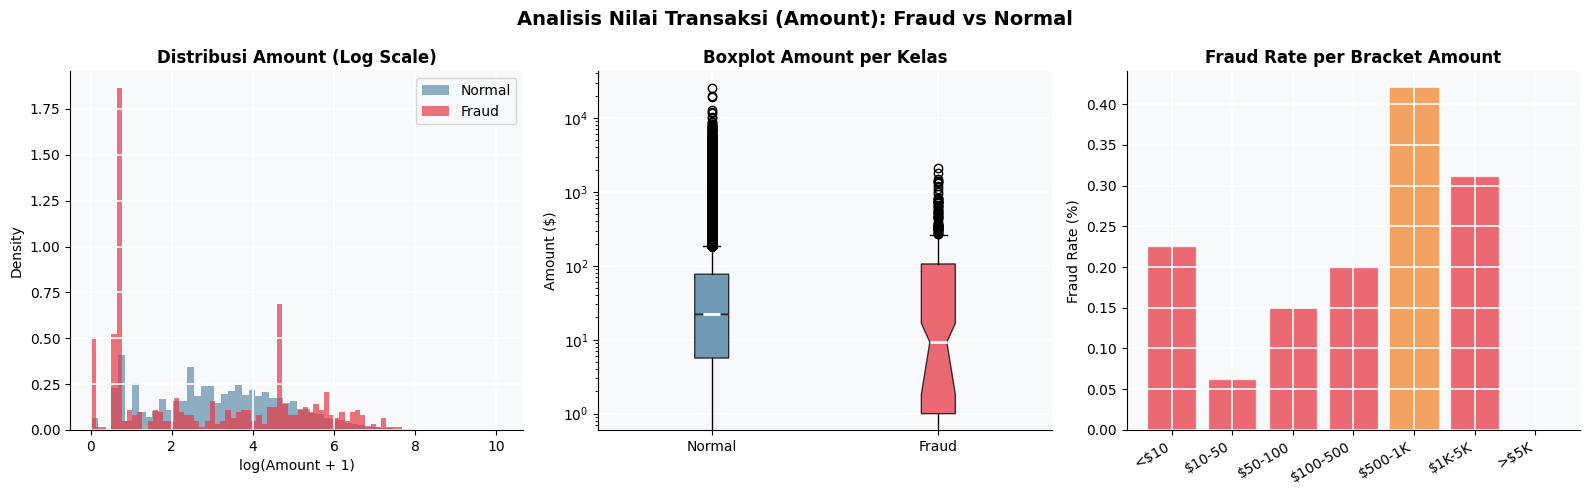

In [12]:
fraud_amounts  = df[df['Class'] == 1]['Amount']
normal_amounts = df[df['Class'] == 0]['Amount']

# Statistik perbandingan
print('Statistik Amount: Fraud vs Normal')
comparison = pd.DataFrame({
    'Fraud'  : fraud_amounts.describe(),
    'Normal' : normal_amounts.describe()
}).round(2)
display(comparison)

# Uji statistik
t_stat, p_val = stats.mannwhitneyu(fraud_amounts, normal_amounts, alternative='two-sided')
print(f'\nMann-Whitney U Test:')
print(f'  p-value = {p_val:.6f} → {"Perbedaan SIGNIFIKAN" if p_val < 0.05 else "Tidak signifikan"} (α=0.05)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi amount (log scale)
axes[0].hist(np.log1p(normal_amounts), bins=60, color=NORMAL_COLOR,
             alpha=0.6, label='Normal', density=True)
axes[0].hist(np.log1p(fraud_amounts),  bins=60, color=FRAUD_COLOR,
             alpha=0.7, label='Fraud',  density=True)
axes[0].set_xlabel('log(Amount + 1)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribusi Amount (Log Scale)', fontweight='bold')
axes[0].legend()

# Boxplot
data_box  = [normal_amounts, fraud_amounts]
bp = axes[1].boxplot(data_box, labels=['Normal', 'Fraud'],
                     patch_artist=True, notch=True,
                     medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(NORMAL_COLOR)
bp['boxes'][1].set_facecolor(FRAUD_COLOR)
for p in bp['boxes']:  p.set_alpha(0.75)
axes[1].set_ylabel('Amount ($)')
axes[1].set_title('Boxplot Amount per Kelas', fontweight='bold')
axes[1].set_yscale('log')

# Amount bracket analysis
bins   = [0, 10, 50, 100, 500, 1000, 5000, np.inf]
labels = ['<$10','$10-50','$50-100','$100-500','$500-1K','$1K-5K','>$5K']
df['amount_bracket'] = pd.cut(df['Amount'], bins=bins, labels=labels)
fraud_rate_bracket = (
    df.groupby('amount_bracket', observed=True)['Class']
    .agg(['sum','count'])
    .assign(fraud_rate=lambda x: x['sum']/x['count']*100)
)
bars = axes[2].bar(range(len(labels)), fraud_rate_bracket['fraud_rate'],
                   color=FRAUD_COLOR, alpha=0.75, edgecolor='white')
max_idx = fraud_rate_bracket['fraud_rate'].argmax()
bars[max_idx].set_color(ACCENT_COLOR)
bars[max_idx].set_alpha(1.0)
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, rotation=30, ha='right')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_title('Fraud Rate per Bracket Amount', fontweight='bold')

plt.suptitle('Analisis Nilai Transaksi (Amount): Fraud vs Normal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Heatmap Korelasi Fitur PCA

Top 10 Fitur Paling Berkorelasi dengan Fraud

Korelasi Positif (cenderung fraud lebih tinggi):
V19    0.0348
V21    0.0404
V2     0.0913
V4     0.1334
V11    0.1549

Korelasi Negatif (cenderung fraud lebih rendah):
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965


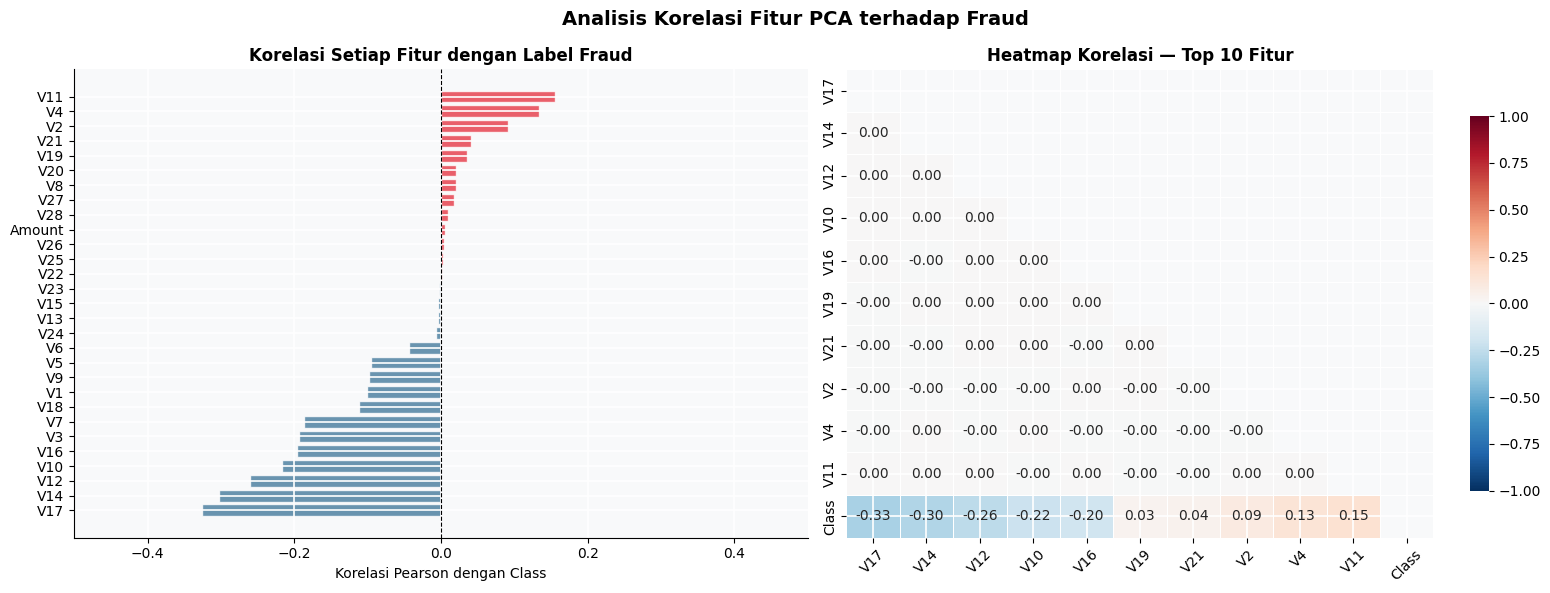

In [13]:
# Korelasi fitur V1-V28 + Amount terhadap Class
pca_cols   = [f'V{i}' for i in range(1, 29)] + ['Amount']
corr_class = df[pca_cols + ['Class']].corr()['Class'].drop('Class').sort_values()

print('Top 10 Fitur Paling Berkorelasi dengan Fraud')
top_positive = corr_class.tail(5)
top_negative = corr_class.head(5)
print('\nKorelasi Positif (cenderung fraud lebih tinggi):')
print(top_positive.round(4).to_string())
print('\nKorelasi Negatif (cenderung fraud lebih rendah):')
print(top_negative.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart korelasi
colors_bar = [FRAUD_COLOR if v > 0 else NORMAL_COLOR for v in corr_class.values]
axes[0].barh(corr_class.index, corr_class.values, color=colors_bar, alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Korelasi Pearson dengan Class')
axes[0].set_title('Korelasi Setiap Fitur dengan Label Fraud', fontweight='bold')
axes[0].set_xlim(-0.5, 0.5)

# Heatmap — top 10 fitur
top10_feats = list(corr_class.head(5).index) + list(corr_class.tail(5).index) + ['Class']
corr_matrix = df[top10_feats].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=axes[1],
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Heatmap Korelasi — Top 10 Fitur', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Analisis Korelasi Fitur PCA terhadap Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Distribusi Fitur PCA (Fraud vs Normal)

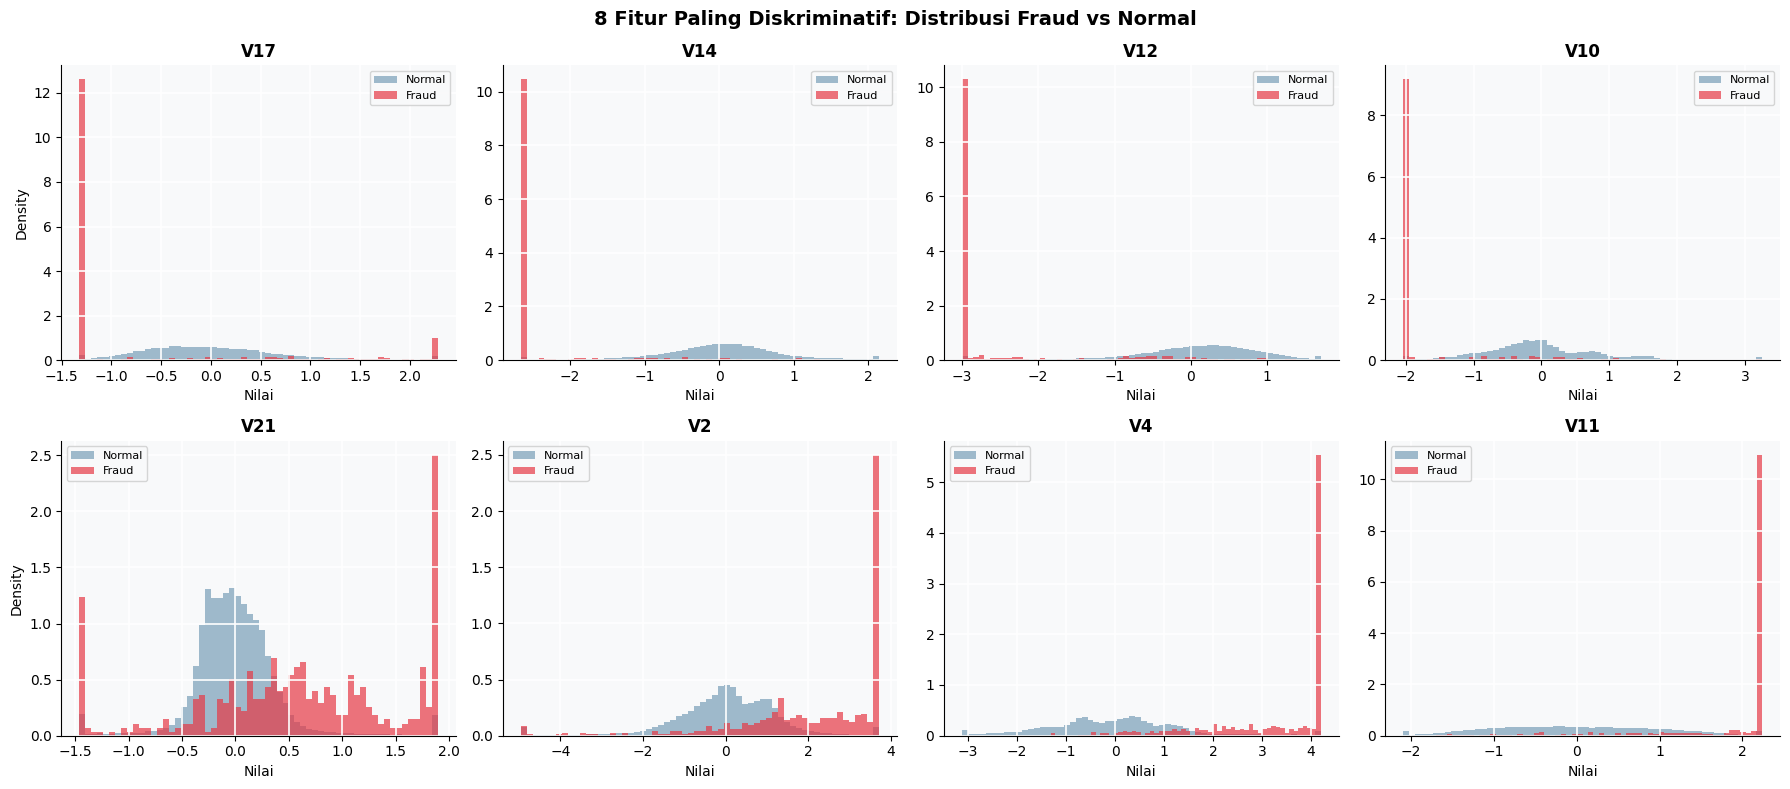

In [14]:
# Ambil 8 fitur paling diskriminatif
top_feats = list(corr_class.head(4).index) + list(corr_class.tail(4).index)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    feat_normal = df[df['Class'] == 0][feat]
    feat_fraud  = df[df['Class'] == 1][feat]

    # Clip outlier ekstrem agar visualisasi lebih bersih
    lo, hi = feat_normal.quantile(0.01), feat_normal.quantile(0.99)
    feat_normal_clipped = feat_normal.clip(lo, hi)
    feat_fraud_clipped  = feat_fraud.clip(lo, hi)

    axes[i].hist(feat_normal_clipped, bins=60, density=True,
                 alpha=0.5, color=NORMAL_COLOR, label='Normal')
    axes[i].hist(feat_fraud_clipped,  bins=60, density=True,
                 alpha=0.7, color=FRAUD_COLOR,  label='Fraud')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Density' if i % 4 == 0 else '')
    axes[i].legend(fontsize=8)

plt.suptitle(
    '8 Fitur Paling Diskriminatif: Distribusi Fraud vs Normal',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plot_05_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ringkasan Insight

In [18]:
fraud_df  = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0]

# Fitur paling diskriminatif
top3_pos = corr_class.tail(3).index.tolist()
top3_neg = corr_class.head(3).index.tolist()

print('   RINGKASAN INSIGHT — EDA FRAUD DETECTION')
print(f"""
DATASET
   • Total transaksi  : {len(df):,}
   • Periode          : {df['Hour'].min()}:00 – {df['Hour'].max()}:59 (2 hari)
   • Fitur            : {df.shape[1]-3} fitur PCA + Time, Amount, Class

CLASS IMBALANCE
   • Transaksi normal : {len(normal_df):,} ({len(normal_df)/len(df)*100:.3f}%)
   • Transaksi fraud  : {len(fraud_df):,}   ({len(fraud_df)/len(df)*100:.3f}%)
   • Rasio            : 1 fraud per {len(normal_df)//len(fraud_df):,} normal
   Implikasi: Gunakan F1-Score / AUC-ROC, bukan Accuracy

NILAI TRANSAKSI (AMOUNT)
   • Median fraud     : ${fraud_df['Amount'].median():.2f}
   • Median normal    : ${normal_df['Amount'].median():.2f}
   • Perbedaan signifikan secara statistik (Mann-Whitney U, p < 0.05)

POLA WAKTU
   • Jam fraud rate tertinggi : {fraud_rate_by_hour.idxmax()}:00
   • Jam dengan volume paling ramai : {total_by_hour.idxmax()}:00

FITUR PALING DISKRIMINATIF
   • Korelasi positif kuat : {', '.join(top3_pos)}
   • Korelasi negatif kuat : {', '.join(top3_neg)}
   → Fitur-fitur ini akan jadi kandidat utama di model ML (Project 3)

REKOMENDASI SELANJUTNYA
   1. Feature scaling: StandardScaler untuk Amount & Time
   2. Handle imbalance: SMOTE atau class_weight='balanced'
   3. Model baseline: Logistic Regression → Random Forest → XGBoost
   4. Evaluasi utama: AUC-ROC + Precision-Recall curve
""")


   RINGKASAN INSIGHT — EDA FRAUD DETECTION

DATASET
   • Total transaksi  : 284,807
   • Periode          : 0:00 – 23:59 (2 hari)
   • Fitur            : 30 fitur PCA + Time, Amount, Class

CLASS IMBALANCE
   • Transaksi normal : 284,315 (99.827%)
   • Transaksi fraud  : 492   (0.173%)
   • Rasio            : 1 fraud per 577 normal
   Implikasi: Gunakan F1-Score / AUC-ROC, bukan Accuracy

NILAI TRANSAKSI (AMOUNT)
   • Median fraud     : $9.25
   • Median normal    : $22.00
   • Perbedaan signifikan secara statistik (Mann-Whitney U, p < 0.05)

POLA WAKTU
   • Jam fraud rate tertinggi : 2:00
   • Jam dengan volume paling ramai : 21:00

FITUR PALING DISKRIMINATIF
   • Korelasi positif kuat : V2, V4, V11
   • Korelasi negatif kuat : V17, V14, V12
   → Fitur-fitur ini akan jadi kandidat utama di model ML (Project 3)

REKOMENDASI SELANJUTNYA
   1. Feature scaling: StandardScaler untuk Amount & Time
   2. Handle imbalance: SMOTE atau class_weight='balanced'
   3. Model baseline: Logistic Regr

---
## Next Steps

Setelah EDA ini selesai, langkah berikutnya di **Project 1** adalah:

1. **`02_sql_queries.ipynb`** — Replikasi insight menggunakan SQL (SQLite / DuckDB)
2. **`03_baseline_model.ipynb`** — Logistic Regression sebagai baseline model

---
*Notebook ini dibuat sebagai bagian dari portfolio.*  
*Dataset: [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)*